# Fit st and fpt with uncertainties in their slopes and breakpoint  
- Use this to find uncertainties in early slopes of FPT and ST fit  
- Then do T test to compare it with early slope of FN  

In [1]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress 
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

In [2]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Piecewise linear fit define function 

In [10]:
data_folder = Path('../../data/results/calculate_final_params')
files=glob.glob(f"{data_folder}/final_*.pkl")
print(files)

['..\\..\\data\\results\\calculate_final_params\\final_bla.pkl', '..\\..\\data\\results\\calculate_final_params\\final_enti.pkl', '..\\..\\data\\results\\calculate_final_params\\final_fn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lha.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lsc.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mob.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mop.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mos.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mrn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_orb.pkl', '..\\..\\data\\results\\calculate_final_params\\final_peri.pkl', '..\\..\\data\\results\\calculate_final_params\\final_pir.pkl', '..\\..\\data\\results\\calculate_final_params\\final_re.pkl']


In [7]:
def fit_piecewiseLinear(data, ax, label):
    # intervals as this is the time when state changes from another state
    
    intervals = data.copy()
    # print(f'original values: {intervals}')
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    x = intervals
    y = log_ccdf

    # Fit piecewise linear model with 2 segments
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    res = my_pwlf.fit(2)

    # Breakpoints returned by pwlf.fit
    breakpoints = res   # e.g. [min_x, breakpoint, max_x]

    # First segment is between breakpoints[0] and breakpoints[1]
    # finding out interval values which contributed to slope 1
    mask_slope1 = (x >= breakpoints[0]) & (x <= breakpoints[1])
    entries_slope1 = x[mask_slope1]

    # print("Entries belonging to slope 1:", entries_slope1.tolist())
     # Entries corresponding to slope 2 (between res[1] and res[2])
    mask2 = (x >= res[1]) & (x <= res[2])
    entries_slope2 = x[mask2]

    # Predict
    y_hat = my_pwlf.predict(x)

    # Plot
    ax.scatter(x, y, label="Data")
    ax.plot(x, y_hat, 'r', label="Piecewise fit")
    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF breakpoint ~ {round(res[1])} {label}")
    ax.legend()

    # Slopes of the fitted lines
    slopes = my_pwlf.calc_slopes()
    se_betas=my_pwlf.standard_errors()
    

    print("Slopes of fitted lines:", slopes)
    print("SE for early slopes",se_betas)

    # Optionally annotate slopes on the plot
    for i, slope in enumerate(slopes):
        ax.text(x.mean(), y_hat.mean() - i*0.5, f"Slope {i+1}: {slope:.3f}", color="blue")

    return {'exp':slopes, 'joint': round(res[1]),'slope_1_entries':entries_slope1.tolist(),'s2':entries_slope2.tolist(),'s1_se':se_betas[1]}


### part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.00279662 -0.01671659]
SE for early slopes [0.03143364 0.00013334 0.00053694]
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.00406947 -0.04091658]
SE for early slopes [1.92308739e-02 7.65427790e-05 1.31231811e-03]
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00428922 -0.03345684]
SE for early slopes [1.50371927e-02 6.27311171e-05 8.28204318e-04]
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00400745 -0.04825549]
SE for early slopes [0.03699672 0.00013386 0.00223533]
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00473713 -0.05207619]
SE for early slopes [1.63166438e-02 6.77318520e-05 1.49184834e-03]
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
S

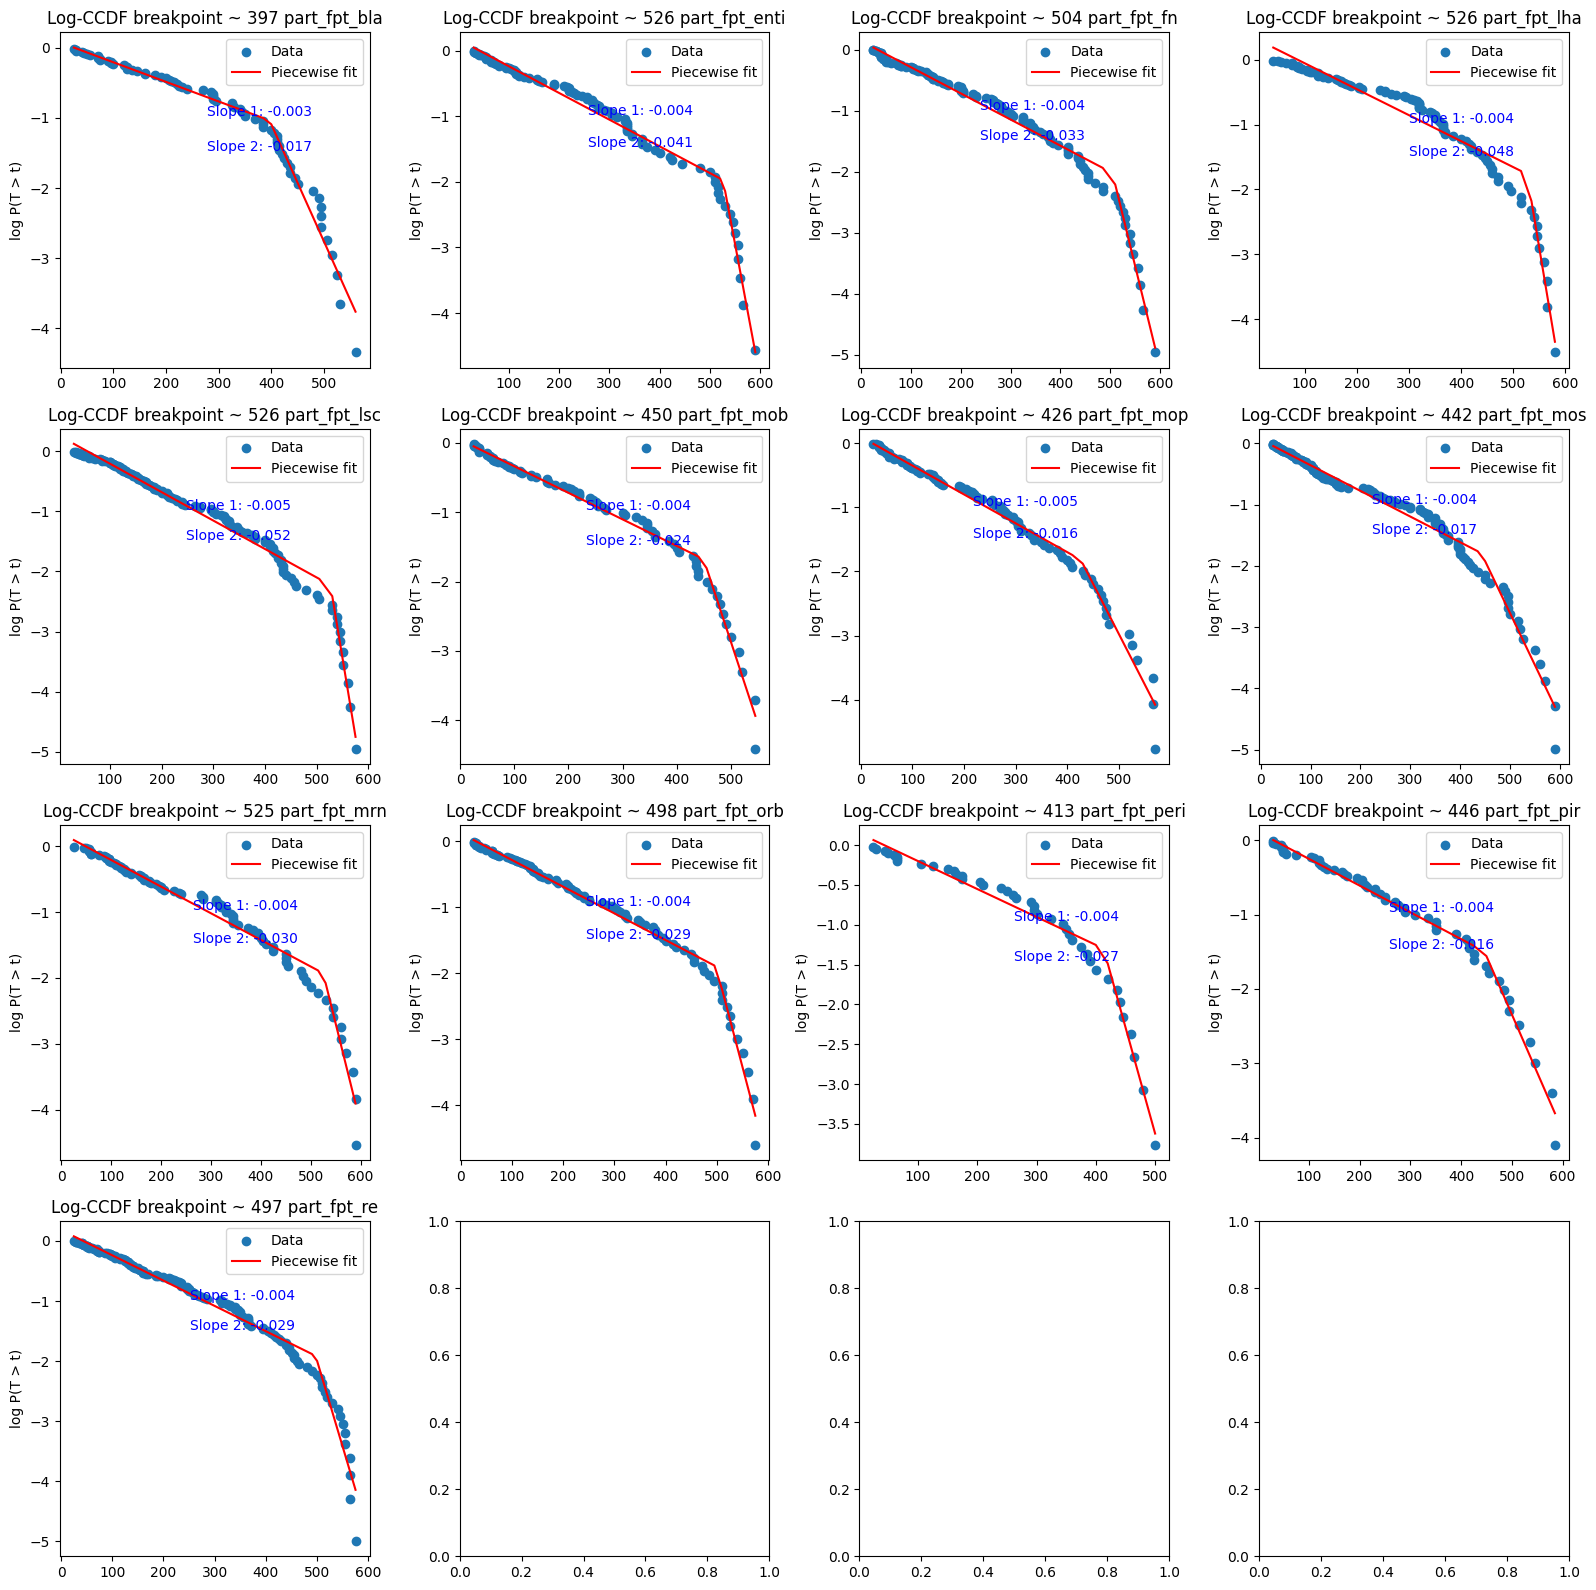

In [8]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [17]:
dict_slp1_se

{'bla': 0.00013333688900138722,
 'enti': 7.654491970197502e-05,
 'fn': 6.27307344071776e-05,
 'lha': 0.00013386333616110816,
 'lsc': 6.773143533036703e-05,
 'mob': 7.896589684963015e-05,
 'mop': 8.26759787104747e-05,
 'mos': 7.911890178545498e-05,
 'mrn': 9.960984202194108e-05,
 'orb': 5.992592138328281e-05,
 'peri': 0.00015528715720235171,
 'pir': 9.548073859279774e-05,
 're': 8.168054151536047e-05}

Applying T test comparing every with FN

In [ ]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -10.1284, P-value: 0.0000
T-statistic: -2.2203, P-value: 0.0264
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -1.9063, P-value: 0.0566
T-statistic: 4.8522, P-value: 0.0000
T-statistic: -4.5434, P-value: 0.0000
T-statistic: 2.1004, P-value: 0.0357
T-statistic: -0.9975, P-value: 0.3185
T-statistic: -2.1177, P-value: 0.0342
T-statistic: -2.8699, P-value: 0.0041
T-statistic: -4.6620, P-value: 0.0000
T-statistic: -6.0684, P-value: 0.0000
T-statistic: -0.7191, P-value: 0.4721


In [38]:
nw

['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']

Storing above data for fig5j  

In [39]:
part_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
part_fpt

{'slp1': {'bla': -0.002796619610971979,
  'enti': -0.004069441841018009,
  'fn': -0.004289178276922395,
  'lha': -0.00400735575441655,
  'lsc': -0.004737129859902477,
  'mob': -0.0038309759431309365,
  'mop': -0.0045071543292842225,
  'mos': -0.00418845919078906,
  'mrn': -0.004039889247590005,
  'orb': -0.004040201034821221,
  'peri': -0.0035083772611709282,
  'pir': -0.0035958723000691657,
  're': -0.004215119180468677},
 'bp': {'bla': 397,
  'enti': 526,
  'fn': 504,
  'lha': 526,
  'lsc': 526,
  'mob': 450,
  'mop': 426,
  'mos': 442,
  'mrn': 525,
  'orb': 498,
  'peri': 413,
  'pir': 446,
  're': 497},
 's_nw': ['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']}

Storing data for fig6

### FPT full

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.00172833 -0.01562133]
SE for early slopes 0.0006713606087754791
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.0024811  -0.01187075]
SE for early slopes 0.00020441389318313723
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00348519 -0.02382408]
SE for early slopes 0.00015133312920680627
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00202074 -0.01663981]
SE for early slopes 0.00034301765981841197
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00243652 -0.0166002 ]
SE for early slopes 0.00023209367867947124
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.00225944 -0.01565076]
SE for early slopes 0.00018363291241037567
Proce

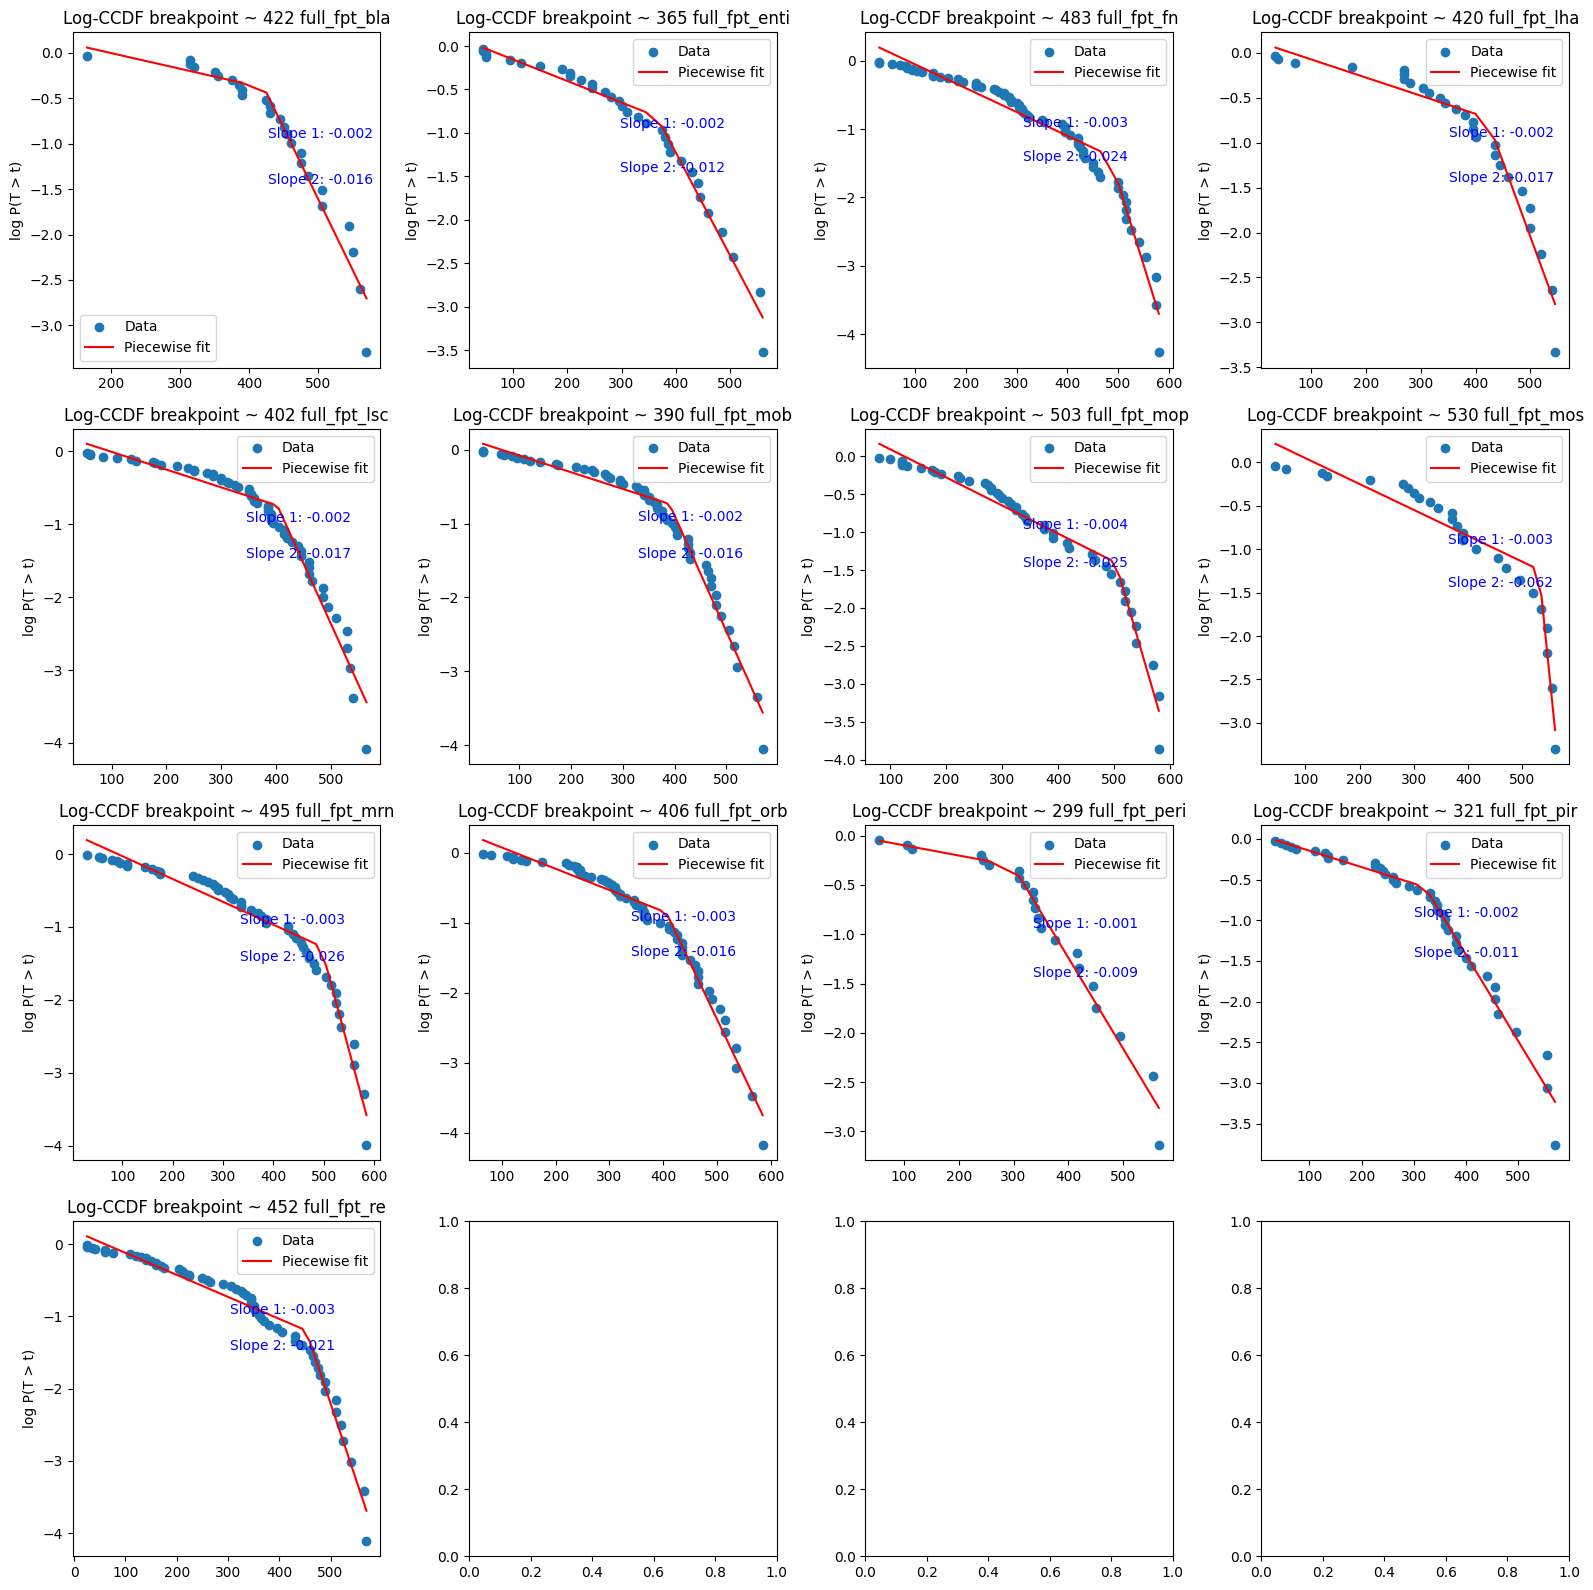

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


t test

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -2.5528, P-value: 0.0107
T-statistic: -3.9479, P-value: 0.0001
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -3.9061, P-value: 0.0001
T-statistic: -3.7848, P-value: 0.0002
T-statistic: -5.1512, P-value: 0.0000
T-statistic: 0.8863, P-value: 0.3754
T-statistic: -1.5428, P-value: 0.1229
T-statistic: -1.5726, P-value: 0.1158
T-statistic: -1.8273, P-value: 0.0677
T-statistic: -5.4124, P-value: 0.0000
T-statistic: -5.3106, P-value: 0.0000
T-statistic: -2.1692, P-value: 0.0301


Storing above for fig5j

In [42]:
full_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
full_fpt

{'slp1': {'bla': -0.0017283327790649319,
  'enti': -0.002481104647830243,
  'fn': -0.003485187146264445,
  'lha': -0.002020739726416017,
  'lsc': -0.0024365184952171636,
  'mob': -0.002259442646654004,
  'mop': -0.0036945290098614122,
  'mos': -0.0029857152327352936,
  'mrn': -0.003136017717760676,
  'orb': -0.0030428953227869615,
  'peri': -0.0010357434756623372,
  'pir': -0.002017500322079742,
  're': -0.003048292631597777},
 'bp': {'bla': 422,
  'enti': 365,
  'fn': 483,
  'lha': 420,
  'lsc': 402,
  'mob': 390,
  'mop': 503,
  'mos': 530,
  'mrn': 495,
  'orb': 406,
  'peri': 299,
  'pir': 321,
  're': 452},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're']}

### Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.01861512 -0.00376398]
SE for early slopes 0.0001844238269921013
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.02865726 -0.0080804 ]
SE for early slopes 0.0004521408399212084
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.02424313 -0.01373869]
SE for early slopes 0.00025220591394754994
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.03244669 -0.00793549]
SE for early slopes 0.0005532935297359866
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.0228427  -0.00791421]
SE for early slopes 0.0003978858401352809
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.02858149 -0.00603429]
SE for early slopes 0.0004357263025801548
Processin

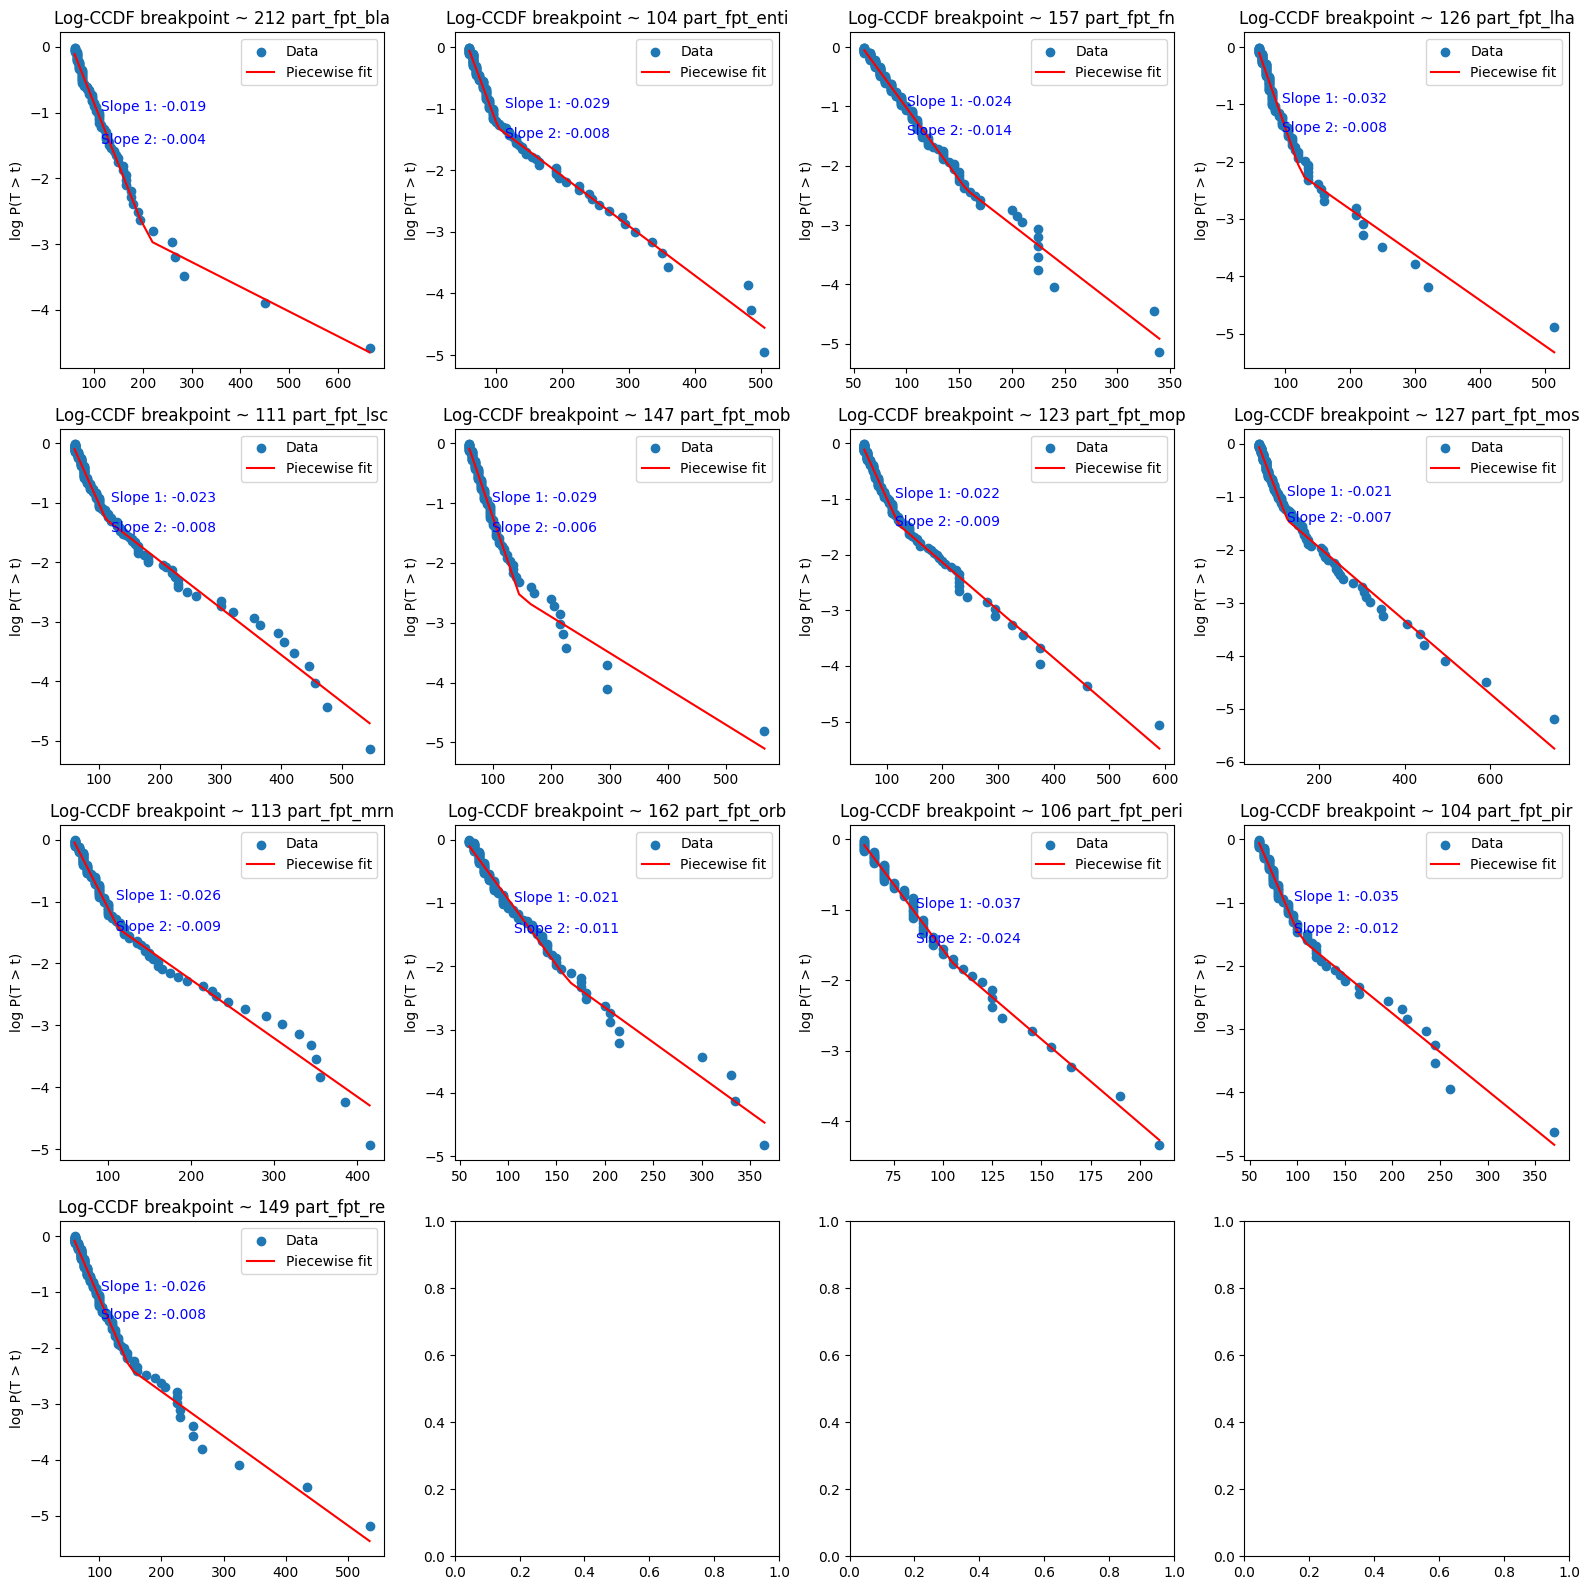

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


T test on early slope part st

In [ ]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -18.0130, P-value: 0.0000
T-statistic: 8.5260, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 13.4913, P-value: 0.0000
T-statistic: -2.9728, P-value: 0.0030
T-statistic: 8.6172, P-value: 0.0000
T-statistic: -6.5305, P-value: 0.0000
T-statistic: -8.8829, P-value: 0.0000
T-statistic: 3.5568, P-value: 0.0004
T-statistic: -8.1558, P-value: 0.0000
T-statistic: 19.1716, P-value: 0.0000
T-statistic: 14.9947, P-value: 0.0000
T-statistic: 3.7198, P-value: 0.0002


In [46]:
part_st={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
part_st['s_nw']

['bla',
 'enti',
 'lha',
 'lsc',
 'mob',
 'mop',
 'mos',
 'mrn',
 'orb',
 'peri',
 'pir',
 're']

Data for figure 5j

In [50]:
reader.data_dump_pkl('results/figures/fig5j_data.pkl',{'fpt_part':part_fpt,
                                                       'fpt_full':full_fpt,
                                                       'st_part':part_st})

In [49]:
full_fpt

{'slp1': {'bla': -0.0017283327790649319,
  'enti': -0.002481104647830243,
  'fn': -0.003485187146264445,
  'lha': -0.002020739726416017,
  'lsc': -0.0024365184952171636,
  'mob': -0.002259442646654004,
  'mop': -0.0036945290098614122,
  'mos': -0.0029857152327352936,
  'mrn': -0.003136017717760676,
  'orb': -0.0030428953227869615,
  'peri': -0.0010357434756623372,
  'pir': -0.002017500322079742,
  're': -0.003048292631597777},
 'bp': {'bla': 422,
  'enti': 365,
  'fn': 483,
  'lha': 420,
  'lsc': 402,
  'mob': 390,
  'mop': 503,
  'mos': 530,
  'mrn': 495,
  'orb': 406,
  'peri': 299,
  'pir': 321,
  're': 452},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're']}

For figure 6

In [9]:
import numpy as np
import pwlf
from scipy import linalg

def fit_piecewiseLinear(data, ax, label):
    # 1. Prepare Data (CCDF logic)
    intervals = np.sort(data.copy())
    n = len(intervals)
    ccdf = 1.0 - np.arange(1, n + 1) / n
    mask = ccdf > 0
    x = intervals[mask]
    y = np.log(ccdf[mask])

    # 2. Fit the model
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breakpoints = my_pwlf.fit(2)  # [min_x, joint, max_x]
    joint = breakpoints[1]
    
    # 3. Calculate Joint Error (Standard Error of the breakpoint)
    # The 'non-linear' method treats the breakpoint as a parameter to find its SE
    try:
        se_all = my_pwlf.standard_errors(method='non-linear')
        se_joint = se_all[-1] # The last value is the SE of the interior joint
    except:
        se_joint = np.nan # Fallback if non-linear method isn't supported in your version

    # 4. Manually Construct Regression Matrix A
    # Column 0: Intercept (constant 1s)
    # Column 1: First slope component (x - min_x)
    # Column 2: Second slope component (x - joint, but only where x > joint)
    col0 = np.ones(len(x))
    col1 = x - breakpoints[0]
    col2 = np.maximum(0, x - joint)
    A = np.column_stack([col0, col1, col2])

    # 5. Calculate Slope Errors using Covariance
    # Degree of freedom = n_samples - n_parameters (3 for a 2-segment fit)
    dof = len(x) - 3
    sigma_sq = my_pwlf.ssr / dof
    
    # Covariance Matrix = sigma_sq * (A^T * A)^-1
    # pinv is used for numerical stability
    cov_beta = sigma_sq * linalg.pinv(np.dot(A.T, A))

    # Slope 1 = Beta 1
    se_slope1 = np.sqrt(cov_beta[1, 1])
    
    # Slope 2 = Beta 1 + Beta 2
    # Var(S2) = Var(B1) + Var(B2) + 2*Cov(B1, B2)
    var_slope2 = cov_beta[1, 1] + cov_beta[2, 2] + 2 * cov_beta[1, 2]
    se_slope2 = np.sqrt(max(0, var_slope2))

    # 6. Plotting and Results
    y_hat = my_pwlf.predict(x)
    slopes = my_pwlf.calc_slopes()

    ax.scatter(x, y, alpha=0.3, label="Data")
    ax.plot(x, y_hat, 'r', linewidth=2, label="Piecewise fit")
    ax.axvline(joint, color='green', linestyle='--', alpha=0.6, 
               label=f"Joint: {joint:.1f} ± {se_joint:.1f}")
    
    ax.set_title(f"Fit for {label}")
    ax.legend()

    print(f"--- Results for {label} ---")
    print(f"Joint:   {joint:.4f} ± {se_joint:.4f}")
    print(f"Slope 1: {slopes[0]:.4f} ± {se_slope1:.4f}")
    print(f"Slope 2: {slopes[1]:.4f} ± {se_slope2:.4f}")

    return {
        'slopes': slopes.tolist(),
        'slopes_se': [se_slope1, se_slope2],
        'joint': joint,
        'joint_se': se_joint
    }

part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   396.7585 ± 4.1875
Slope 1: -0.0028 ± 0.0001
Slope 2: -0.0167 ± 0.0005
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   525.8765 ± 2.1109
Slope 1: -0.0041 ± 0.0001
Slope 2: -0.0409 ± 0.0013
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   504.3617 ± 2.0564
Slope 1: -0.0043 ± 0.0001
Slope 2: -0.0335 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   526.3518 ± 3.0652
Slope 1: -0.0040 ± 0.0001
Slope 2: -0.0482 ± 0.0022
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   526.4456 ± 1.3933
Slope 1: -0.0047 ± 0.0001
Slope 2: -0.0521 ± 0.0015
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

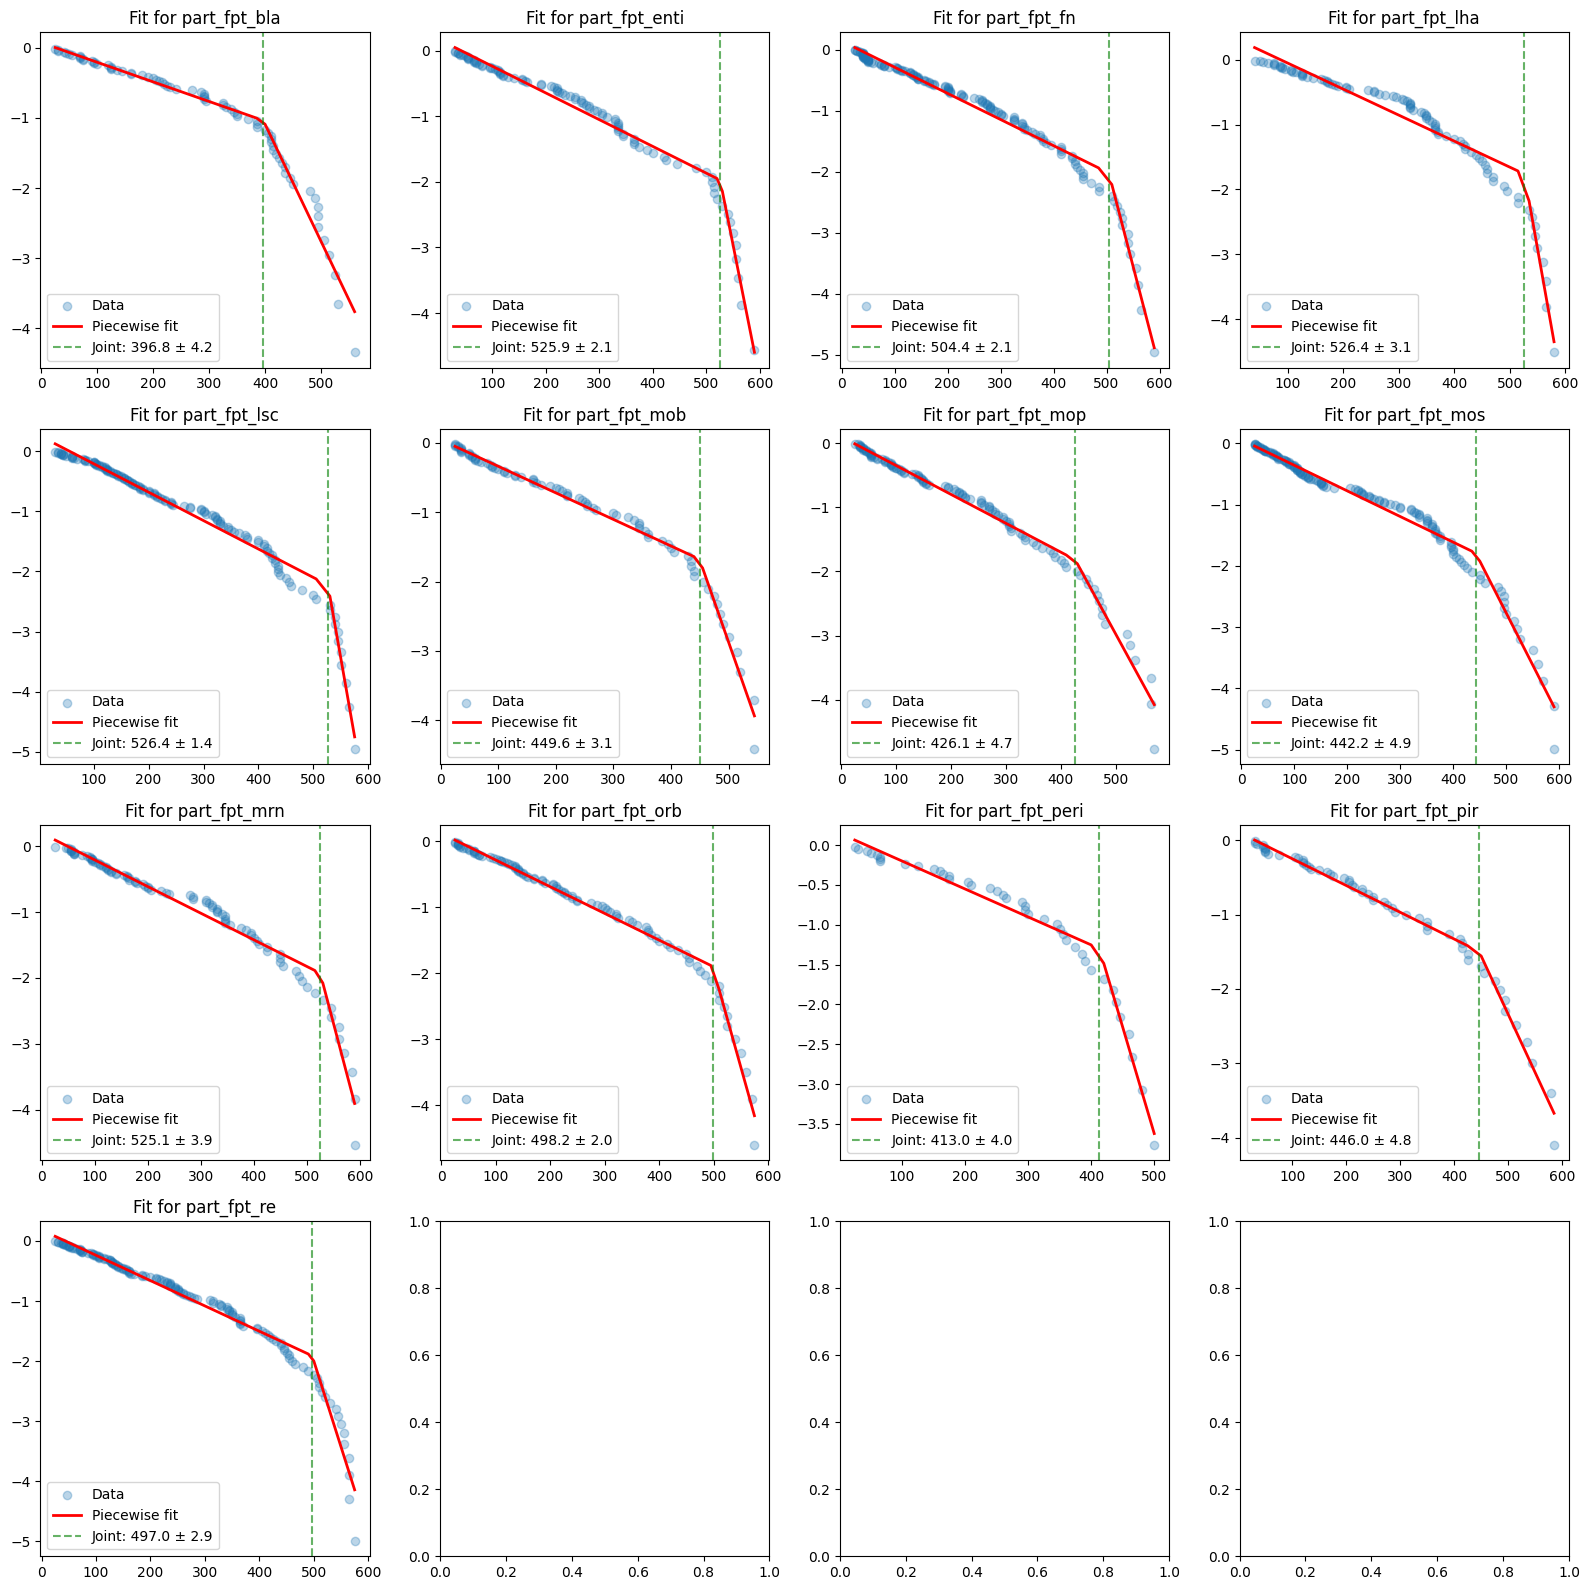

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp1_se={}
dict_exp2 = {}
dict_exp2_se={}
dict_joint = {}
dict_joint_se={}




for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']
    
   
    

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [19]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pfpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pfpt)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.002797  0.000133 -0.016718  0.000455  396.758468  4.187468
enti -0.004069  0.000077 -0.040910  0.001275  525.876518  2.110860
fn   -0.004289  0.000063 -0.033459  0.000797  504.361744  2.056377
lha  -0.004007  0.000134 -0.048244  0.002172  526.351760  3.065219
lsc  -0.004737  0.000068 -0.052083  0.001460  526.445591  1.393251
mob  -0.003831  0.000079 -0.023695  0.000613  449.613872  3.069903
mop  -0.004507  0.000083 -0.015713  0.000397  426.068603  4.662702
mos  -0.004188  0.000079 -0.016996  0.000423  442.225293  4.912398
mrn  -0.004040  0.000100 -0.030478  0.001212  525.101955  3.892902
orb  -0.004040  0.000060 -0.029440  0.000665  498.157791  2.035392
peri -0.003508  0.000155 -0.026689  0.001042  413.045735  3.998521
pir  -0.003596  0.000095 -0.015654  0.000443  446.009266  4.775999
re   -0.004215  0.000082 -0.028611  0.000832  496.994304  2.894653


Full FPT

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for full_fpt_bla ---
Joint:   421.6916 ± 8.6594
Slope 1: -0.0017 ± 0.0007
Slope 2: -0.0156 ± 0.0008
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for full_fpt_enti ---
Joint:   365.1360 ± 7.7420
Slope 1: -0.0025 ± 0.0002
Slope 2: -0.0119 ± 0.0004
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for full_fpt_fn ---
Joint:   482.9585 ± 4.9646
Slope 1: -0.0035 ± 0.0002
Slope 2: -0.0238 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for full_fpt_lha ---
Joint:   420.3136 ± 9.3868
Slope 1: -0.0020 ± 0.0003
Slope 2: -0.0166 ± 0.0010
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for full_fpt_lsc ---
Joint:   402.3546 ± 5.6174
Slope 1: -0.0024 ± 0.0002
Slope 2: -0.0166 ± 0.0006
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

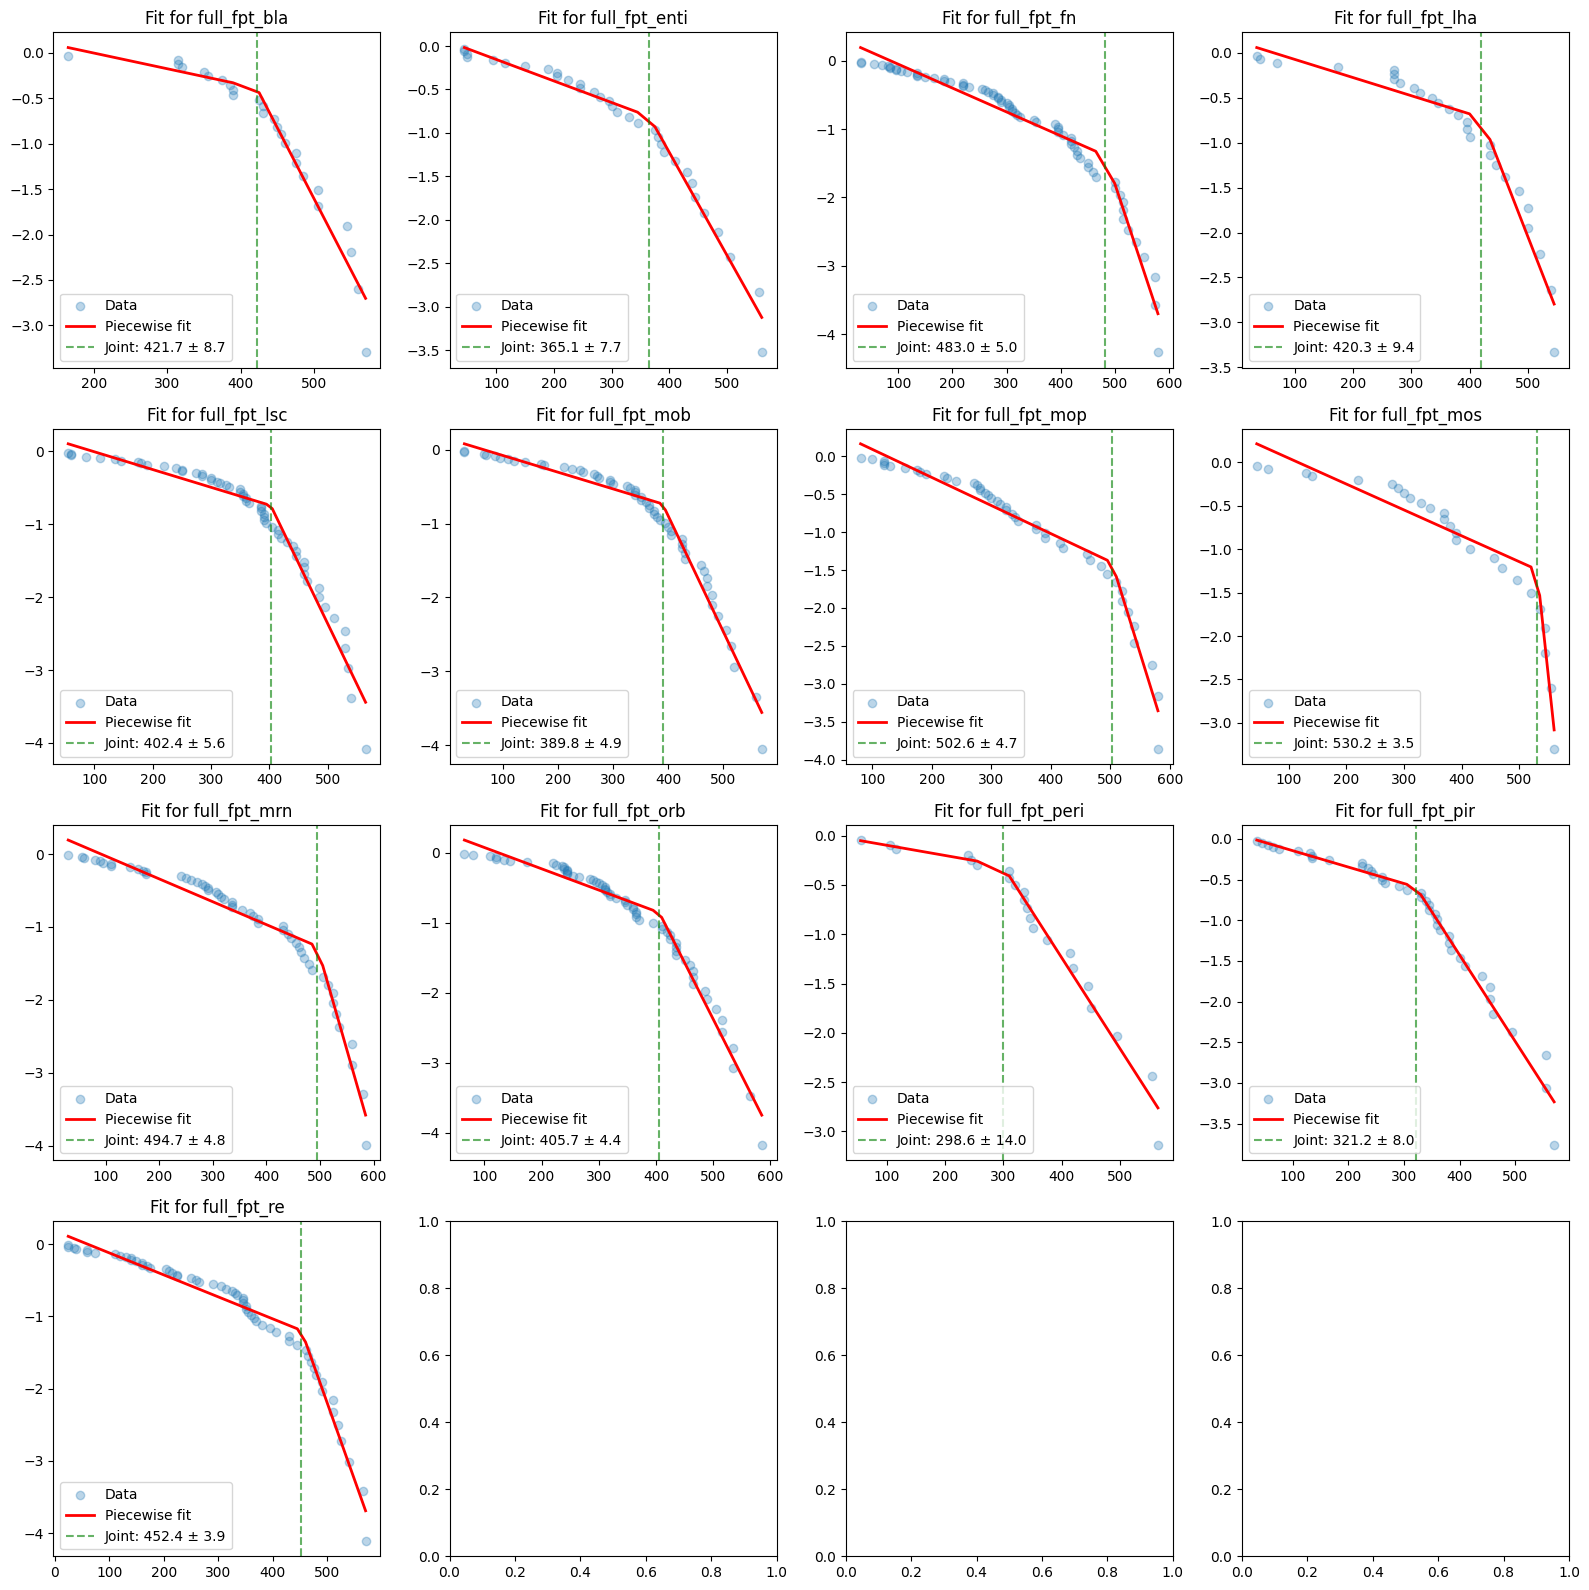

In [20]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [21]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_ffpt = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_ffpt)


          exp1   exp1_se      exp2   exp2_se       joint   joint_se
bla  -0.001729  0.000671 -0.015622  0.000799  421.691597   8.659436
enti -0.002481  0.000204 -0.011871  0.000413  365.135972   7.741959
fn   -0.003485  0.000151 -0.023822  0.000951  482.958545   4.964638
lha  -0.002021  0.000343 -0.016640  0.001013  420.313581   9.386783
lsc  -0.002436  0.000232 -0.016599  0.000557  402.354604   5.617384
mob  -0.002259  0.000184 -0.015648  0.000442  389.784045   4.903013
mop  -0.003695  0.000181 -0.025228  0.001225  502.606974   4.711456
mos  -0.002986  0.000286 -0.061924  0.005165  530.193919   3.457829
mrn  -0.003136  0.000162 -0.025646  0.001090  494.705993   4.836257
orb  -0.003043  0.000189 -0.016160  0.000418  405.713362   4.416008
peri -0.001035  0.000427 -0.009226  0.000368  298.568720  14.011567
pir  -0.002016  0.000231 -0.010619  0.000311  321.190746   7.990080
re   -0.003049  0.000133 -0.021235  0.000669  452.424084   3.905225


Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
--- Results for part_fpt_bla ---
Joint:   212.0065 ± 3.2484
Slope 1: -0.0186 ± 0.0002
Slope 2: -0.0038 ± 0.0002
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
--- Results for part_fpt_enti ---
Joint:   103.7231 ± 1.2625
Slope 1: -0.0287 ± 0.0005
Slope 2: -0.0081 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
--- Results for part_fpt_fn ---
Joint:   157.0570 ± 3.9872
Slope 1: -0.0242 ± 0.0003
Slope 2: -0.0137 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
--- Results for part_fpt_lha ---
Joint:   125.9152 ± 2.1867
Slope 1: -0.0324 ± 0.0006
Slope 2: -0.0079 ± 0.0003
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
--- Results for part_fpt_lsc ---
Joint:   111.5027 ± 1.8736
Slope 1: -0.0228 ± 0.0004
Slope 2: -0.0079 ± 0.0001
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
--

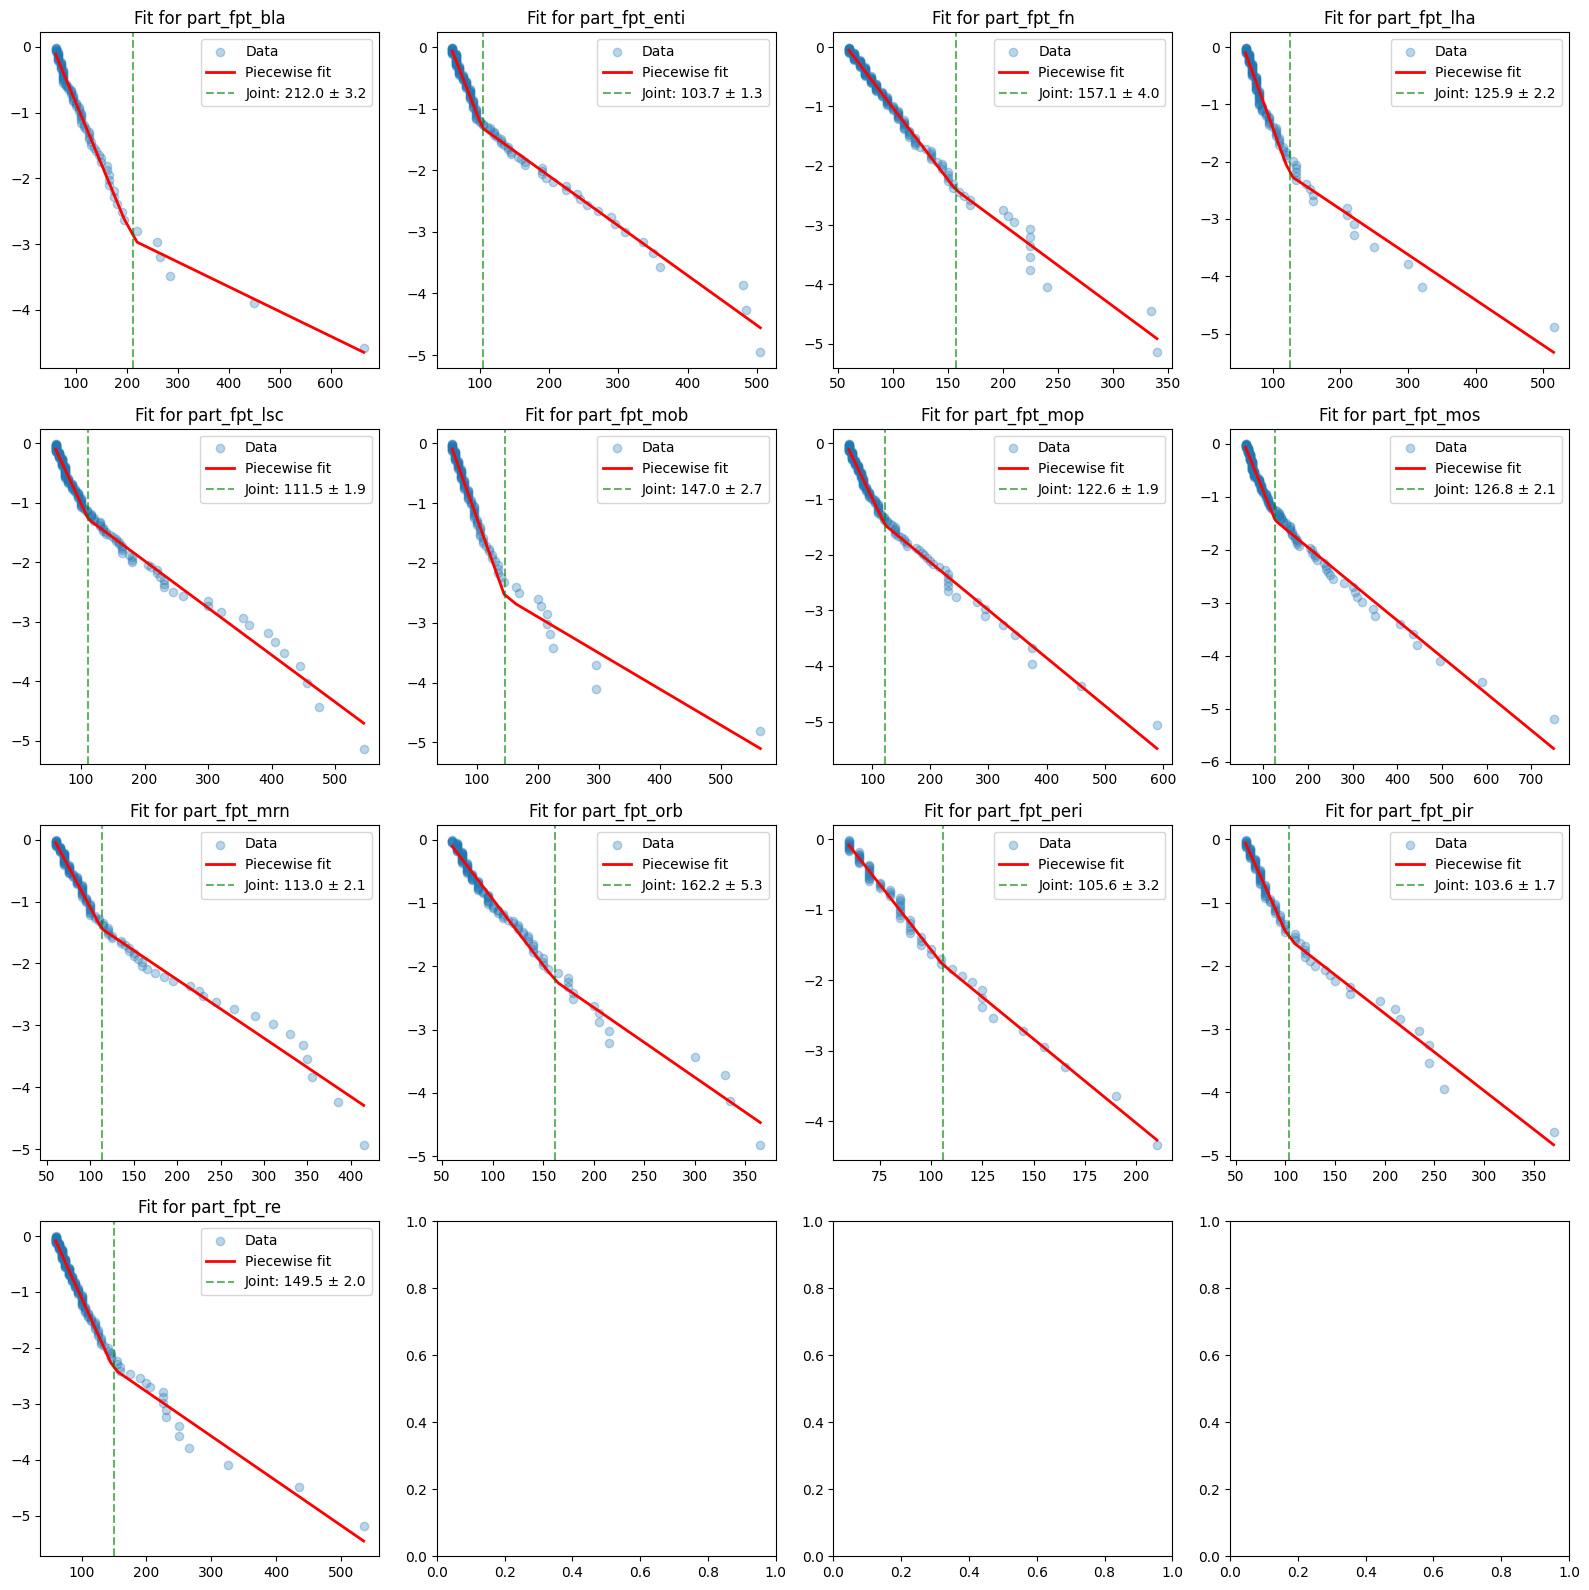

In [ ]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_st_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    dict_exp1[nw] = p['slopes'][0]
    dict_exp1_se[nw]=p['slopes_se'][0]
    dict_exp2[nw] = p['slopes'][1]
    dict_exp2_se[nw]=p['slopes_se'][1]
    dict_joint[nw]=p['joint']
    dict_joint_se[nw]=p['joint_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [23]:


# assuming you already have dict_exp1, dict_exp1_se, dict_exp2, dict_exp2_se, dict_joint, dict_joint_se

df_pst = pd.DataFrame({
    'exp1': dict_exp1,
    'exp1_se': dict_exp1_se,
    'exp2': dict_exp2,
    'exp2_se': dict_exp2_se,
    'joint': dict_joint,
    'joint_se': dict_joint_se
})

print(df_pst)


          exp1   exp1_se      exp2   exp2_se       joint  joint_se
bla  -0.018616  0.000184 -0.003764  0.000155  212.006451  3.248383
enti -0.028658  0.000452 -0.008080  0.000099  103.723071  1.262472
fn   -0.024243  0.000252 -0.013738  0.000324  157.056952  3.987247
lha  -0.032446  0.000553 -0.007935  0.000275  125.915165  2.186740
lsc  -0.022840  0.000398 -0.007914  0.000101  111.502671  1.873637
mob  -0.028580  0.000436 -0.006034  0.000267  147.010882  2.668692
mop  -0.021730  0.000291 -0.008588  0.000106  122.585602  1.909340
mos  -0.020673  0.000313 -0.006895  0.000094  126.826299  2.104161
mrn  -0.026259  0.000508 -0.009443  0.000165  112.997794  2.110926
orb  -0.020824  0.000334 -0.011017  0.000361  162.171505  5.281227
peri -0.037071  0.000620 -0.023836  0.000551  105.622959  3.185789
pir  -0.034770  0.000655 -0.012223  0.000248  103.586071  1.703466
re   -0.025589  0.000259 -0.007973  0.000177  149.451637  2.019060


Storing data for figure 6 all lastparams

In [24]:
reader.data_dump_pkl('results/figures/fig6_data.pkl',{'full_fpt':df_ffpt,'part_fpt':df_pfpt,'part_st':df_pst})